In [59]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,classification_report,accuracy_score,confusion_matrix, ConfusionMatrixDisplay
import nltk 
nltk.download('stopword',quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


[nltk_data] Error loading stopword: Package 'stopword' not found in
[nltk_data]     index


In [6]:
df = pd.read_csv('spam.csv',encoding='latin-1')[['v1','v2']]
df.head()
df.columns=['label','text']


In [8]:
df.describe()
df.isnull().sum()

label    0
text     0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True,drop=True)
df.shape

(5169, 2)

In [13]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


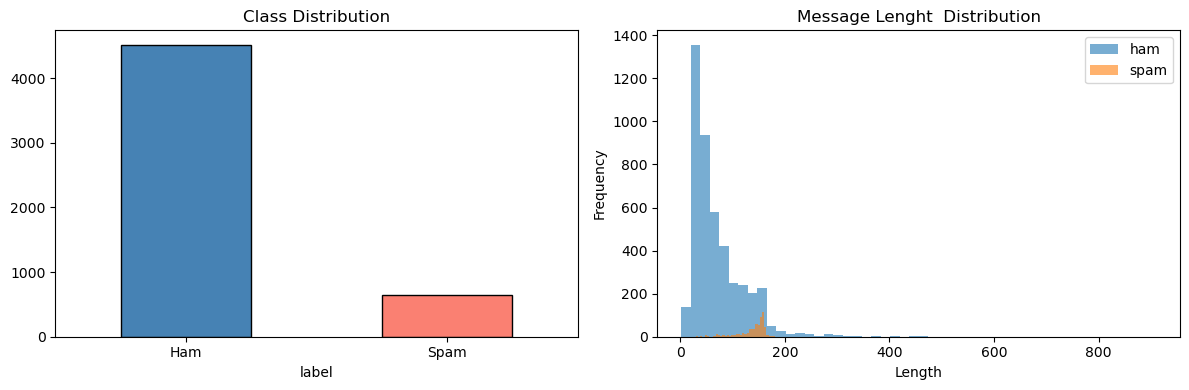

In [29]:
round(df['label'].value_counts(normalize=True)['ham']*100,2)
fig , axes = plt.subplots(1,2,figsize=(12,4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Ham', 'Spam'], rotation=0)

df['msg_len']= df['text'].apply(len)
df.groupby('label')['msg_len'].plot(kind='hist',bins=50,alpha = 0.6, legend = True ,ax=axes[1])
axes[1].set_title("Message Lenght  Distribution")
axes[1].set_xlabel('Length')
plt.tight_layout()
plt.show()

In [39]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       tagge

True

In [43]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import nltk
nltk.download('stopwords')   # run once

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def process(text):
    text = text.lower()   # FIXED
    text = re.sub(r'\d+', '', text)   # FIXED
    text = text.translate(str.maketrans('', '', string.punctuation))   # FIXED
    
    tokens = [ps.stem(w) for w in text.split() if w not in stop_words]  # stem not stream
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(process)
df[['text', 'clean_text']].head(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pranj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...


In [44]:
df['label_enc']=df['label'].map({'ham':0,'spam':1})
x_train,x_test,y_train,y_test=train_test_split(
    df['clean_text'],df['label_enc'],
    test_size=0.2,random_state=42,stratify=df['label_enc']
    )

print('Train:', len(x_train), "Test:",len(x_test))


Train: 4135 Test: 1034


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [47]:
tfid = TfidfVectorizer(max_features=3000,ngram_range=(1,2))
x_train_vec= tfid.fit_transform(x_train)
x_test_vec = tfid.transform(x_test)

In [49]:
x_test_vec.shape

(1034, 3000)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import joblib

In [57]:
models={
    'Naive Bayers': MultinomialNB(alpha=0.1),
    'Linear SVC' : LinearSVC(C=5,max_iter=1000),
    'LogisticRegression':LogisticRegression(C=1.0)
}
results={}

for name, model in models.items():
    model.fit(x_train_vec,y_train)
    preds=model.predict(x_test_vec)
    acc=accuracy_score(y_test,preds)
    results[name] = acc
    print(f'--- {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))

    

--- Naive Bayers ---
Accuracy: 0.9739
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.96      0.83      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034

--- Linear SVC ---
Accuracy: 0.9768
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.95      0.86      0.90       131

    accuracy                           0.98      1034
   macro avg       0.96      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034

--- LogisticRegression ---
Accuracy: 0.9652
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.73      0.84       131

    accuracy                           0.97      1034
   macro a

Best model: Linear SVC (0.9768)


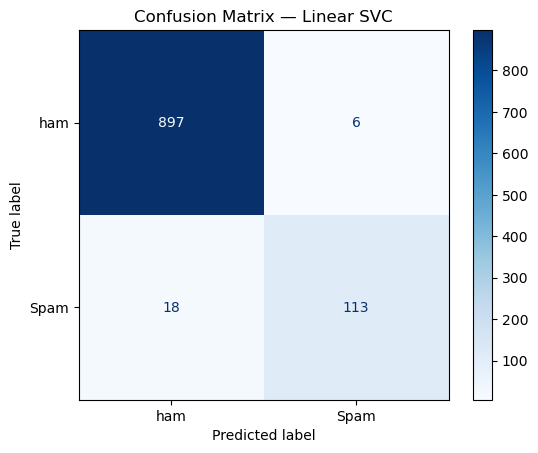

In [61]:
best_name = max(results,key=results.get)
best_modle = models[best_name]
print(f'Best model: {best_name} ({results[best_name]:.4f})')

cm = confusion_matrix(y_test,best_modle.predict(x_test_vec))
disp = ConfusionMatrixDisplay(cm,display_labels=['ham','Spam'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

In [62]:
import joblib

In [64]:
joblib.dump(best_modle, 'spam_model.pkl')
joblib.dump(tfid, 'tfidf_vectorizer.pkl')
print('Saved spam_model.pkl and tfidf_vectorizer.pkl')

Saved spam_model.pkl and tfidf_vectorizer.pkl


In [66]:
def predict_sms(message):
    clean = process(message)
    vec   = tfid.transform([clean])
    pred  = best_modle.predict(vec)[0]
    return 'SPAM' if pred == 1 else 'HAM'

test_msgs = [
    'WINNER!! You have been selected for a £900 prize. Call now!',
    'Hey, are you coming to the party tonight?',
    'Free entry in 2 a weekly comp to win FA Cup Final tkts',
    'Can you pick up milk on the way home?'
]

for msg in test_msgs:
    print(f'[{predict_sms(msg)}] {msg}')

[SPAM] WINNER!! You have been selected for a £900 prize. Call now!
[HAM] Hey, are you coming to the party tonight?
[SPAM] Free entry in 2 a weekly comp to win FA Cup Final tkts
[HAM] Can you pick up milk on the way home?
